In [20]:
# Plota saidas do SWAN com arquivos .mat (e nc?)

In [21]:
import pandas as pd
import h5py
import xarray as xr
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipympl

In [22]:
pth = 'RJ/Outputs/'
fln = 'RJ_teste_01'

grid = scipy.io.loadmat(pth + f'{fln}_grid.mat')
param = scipy.io.loadmat(pth + f'{fln}_param.mat')
bot = scipy.io.loadmat(pth + f'{fln}_bot.mat')

In [23]:
bot = bot['Botlev']
swh = param['Hsig']
lons = grid['Xp']
lats = grid['Yp']
lat = lats[:, 0]
lon = lons[0, :]

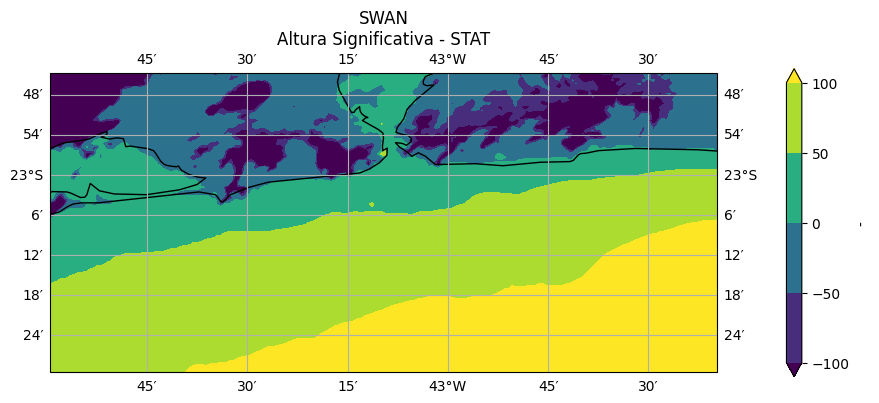

In [24]:
%matplotlib inline

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                    #    subplot_kw={'projection': ccrs.Mercator()}
                       )

ax.coastlines(resolution='10m')

c = ax.contourf(lon, lat, np.flipud(bot),
                levels=[-100, -50, 0, 50, 100],
                extend='both',
                cmap='viridis',
                transform=ccrs.PlateCarree(),
                # transform=ccrs.Mercator(),
                )

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

fig.colorbar(c, ax=ax, orientation='vertical',
                                        shrink=0.4,  # Reduz o tamanho da barra
                                        pad=0.09,  # Aproxima da figura
                                        aspect=20,  # Ajusta proporção altura/largura
                                        fraction=0.05,  # Reduz o espaço ocupado, 
                                        label='-')

ax.set_title('SWAN\nAltura Significativa - STAT')

# ax.set_extent([-46, -42, -24.0, -22.3], crs=ccrs.PlateCarree())
ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=ccrs.PlateCarree())

plt.show()
# fig.savefig('fig/RJ_1km_ERA5_050_20241101to20241130/mapa_Hs_{:%Y%m%d%H}.png'.format(datet), bbox_inches='tight')
# plt.close('all')

/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


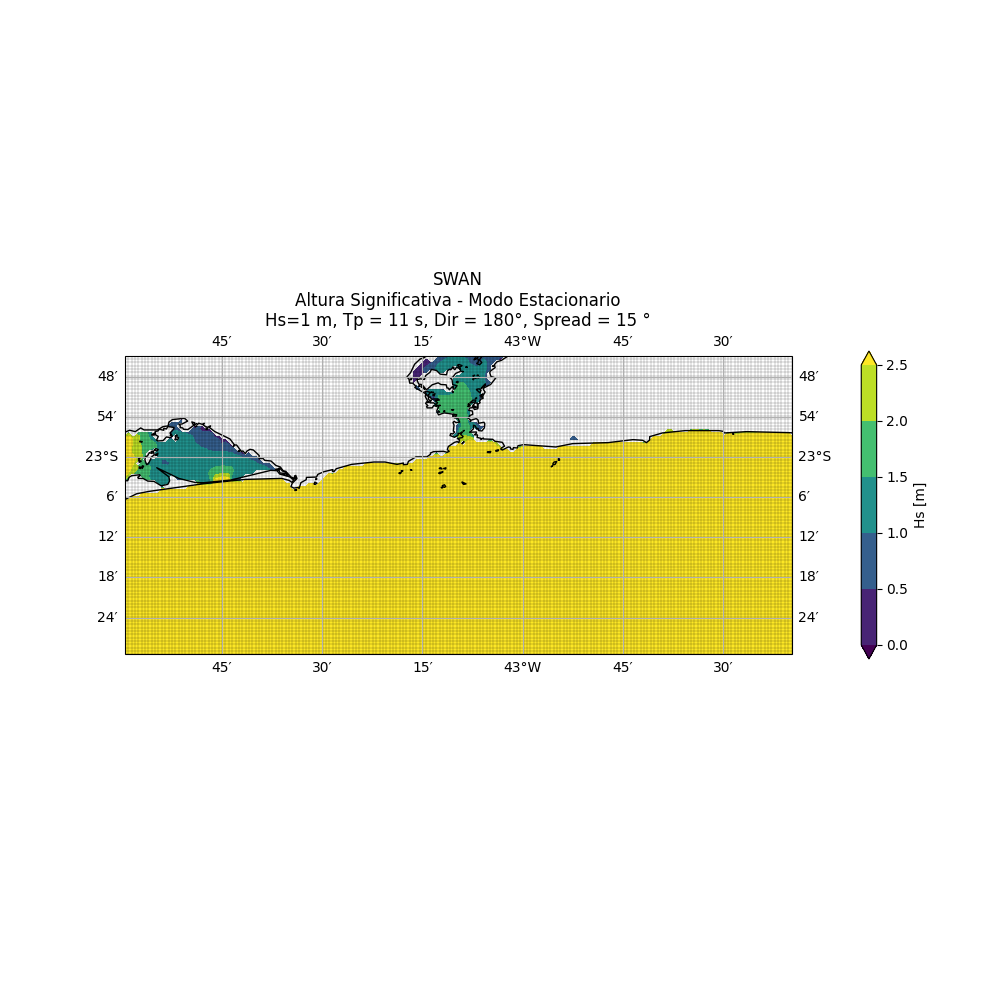

In [32]:
%matplotlib ipympl
# %matplotlib inline

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()}
                    #    subplot_kw={'projection': ccrs.Mercator()}
                       )

# ax.coastlines(resolution='10m')
ax.add_feature(cfeature.GSHHSFeature(scale='high'), edgecolor='black')

c = ax.contourf(lon, lat, swh,
                # levels=[-100, -50, 0, 50, 100],
                levels=np.arange(0, 3, 0.5),
                extend='both',
                cmap='viridis',
                transform=ccrs.PlateCarree(),
                # transform=ccrs.Mercator(),
                )

# # Adicionar as linhas de grade com a resolução do modelo
for lat1 in lat:
    ax.plot(lon, np.full_like(lon, lat1), color='black', linewidth=0.2, alpha=0.7)  # Linhas horizontais (latitude)

for lon1 in lon:
    ax.plot(np.full_like(lat, lon1), lat, color='black', linewidth=0.2, alpha=0.7)  # Linhas verticais (longitude)

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

fig.colorbar(c, ax=ax, orientation='vertical',
                                        shrink=0.4,  # Reduz o tamanho da barra
                                        pad=0.09,  # Aproxima da figura
                                        aspect=20,  # Ajusta proporção altura/largura
                                        fraction=0.05,  # Reduz o espaço ocupado, 
                                        label='Hs [m]')

ax.set_title('SWAN\nAltura Significativa - Modo Estacionario\nHs=1 m, Tp = 11 s, Dir = 180°, Spread = 15 °')

# ax.set_extent([-43.9, -42.5, -23.4, -22.8], crs=ccrs.PlateCarree())
ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=ccrs.PlateCarree())

plt.show()
# fig.savefig('fig/RJ_1km_ERA5_050_20241101to20241130/mapa_Hs_{:%Y%m%d%H}.png'.format(datet), bbox_inches='tight')
# plt.close('all')

In [26]:
# # Criar o DataArray usando xarray

# swh_data = xr.DataArray(Hss, 
#                         coords=[datas, latitude, longitude], 
#                         dims=["time", "latitude", "longitude"], 
#                         name="significant_wave_height")

# swh_data.attrs["units"] = "Meters"
# swh_data.attrs["long_name"] = "Significant Wave Height"

# ds_swh = xr.Dataset({"swh": swh_data})
# # ds_swh.to_netcdf('RJ/Outputs/RJ_5km/H-sig.nc')

In [27]:
# # carrega era5

# ds_era5 = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-wave_stepType-instant.nc')


In [28]:
# df_swh = ds_swh.sel(latitude=-23.30, longitude=-43.3, method='nearest').to_dataframe()
# df_era5 = ds_era5.sel(latitude=-23.2765071, longitude=-43.2760040, method='nearest').to_dataframe()
# df_swh

In [29]:
# df_swh.swh.plot(figsize=(8, 4), grid='on')
# df_era5.swh.plot(figsize=(8, 4), grid='on')
